# K - Nearest Neighbours 

## Setup

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [2]:
try:
    X_train = joblib.load("X_train.pkl")
    X_test = joblib.load("X_test.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

Loaded successfully
X_train: (3996, 42) y_train: (3996,)
X_test : (1000, 42) y_test : (1000,)


## Results Log
Tracks accuracy at every stage of the notebook (baseline, tuning, cross-validation, erc.) so improvements can be compared side by side rather than only seeing the most recently printed number.

In [3]:
results_log = []

def log_result(name, y_true, y_pred):
    """Log accuracy from a set of predictions."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc})
    print(f"[Logged] {name}: {acc:.4f}")
    return acc

def log_value(name, acc):
    """Log an already-computed accuracy value (e.g. a CV mean)."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc})
    print(f"[Logged] {name}: {acc:.4f}")
    return acc

## Baseline Model
untuned KNN model, \n`n_neighbors=15` chosen arbitrarily

In [4]:
# create, train, and evaluate a baseline model
try:
    knn = KNeighborsClassifier(n_neighbors=15, weights='uniform')
    knn.fit(X_train, y_train)
    knn_pred = knn.predict(X_test)
except (ValueError, RuntimeError) as e:
    print(f"Error training baseline KNN model: {e}")
else:
    knn_accuracy = accuracy_score(y_test, knn_pred)
    print("Baseline Accuracy:", knn_accuracy)
    print(classification_report(y_test, knn_pred))
    log_result("Baseline (n_neighbors=15)", y_test, knn_pred)

Baseline Accuracy: 0.777
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       438
           1       0.79      0.82      0.80       562

    accuracy                           0.78      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.78      0.78      0.78      1000

[Logged] Baseline (n_neighbors=15): 0.7770


## Hyperparameter Tuning
Grid Search is used to find the best `n_neighbors` and `metric`. `weights` is fixed to `'uniform'` throughout

In [5]:
param_grid = {
    "n_neighbors": range(1, 61),
    "weights": ["uniform"],
    "metric": ["euclidean", "manhattan"]
}

try:
    grid_search = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid,
        cv=10,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_knn = grid_search.best_estimator_
    print("Best Hyperparameters:", grid_search.best_params_)
    print(f"Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")
    log_value("Grid Search (10-fold CV, best score)", grid_search.best_score_)

Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best Cross-Validated Accuracy: 0.8191
[Logged] Grid Search (10-fold CV, best score): 0.8191


## Best Model Evaluation
The tuned model obtained from Grid Search is evaluated on the test set, including a training-vs-testing accuracy comparison to check for overfitting or underfitting.

In [6]:
try:
    best_pred = best_knn.predict(X_test)
    train_accuracy = best_knn.score(X_train, y_train)
    test_accuracy = best_knn.score(X_test, y_test)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating best model: {e}")
else:
    print("Training Accuracy:", train_accuracy)
    print("Testing Accuracy:", test_accuracy)
    print()
    print(classification_report(y_test, best_pred))
    log_result("Grid Search Tuned (test set)", y_test, best_pred)

Training Accuracy: 0.9061561561561562
Testing Accuracy: 0.807

              precision    recall  f1-score   support

           0       0.79      0.76      0.78       438
           1       0.82      0.84      0.83       562

    accuracy                           0.81      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.81      0.81      1000

[Logged] Grid Search Tuned (test set): 0.8070


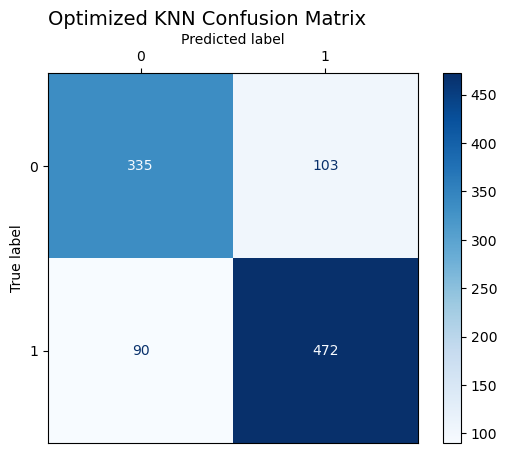

In [7]:
try:
    cm = confusion_matrix(y_test, best_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.gca().xaxis.tick_top()
    plt.gca().xaxis.set_label_position("top")
    plt.title("Optimized KNN Confusion Matrix", fontsize=14, loc='left')
    plt.xlabel("Predicted label", fontsize=10)
    plt.ylabel("True label", fontsize=10)

    plt.show()
except (ValueError, NameError) as e:
    print(f"Error plotting confusion matrix: {e}")

## Model Stability — Cross-Validation & Accuracy vs. K 
10-fold cross-validation checks how consistent the model's accuracy is across different subsets of the training data. The closest honest equivalent is the **Accuracy vs. K plot** below — it plays the same diagnostic role (showing how a key parameter affects performance, and confirming the chosen value sits at a genuine peak rather than an arbitrary point)

Fold scores: [0.8175     0.8175     0.8225     0.8375     0.8275     0.8175
 0.81704261 0.83709273 0.8245614  0.77192982]
Average CV Accuracy: 0.8190626566416042
[Logged] 10-Fold Cross-Validation (mean): 0.8191


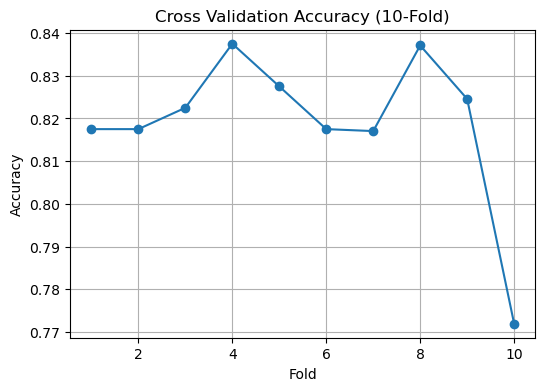

In [8]:
try:
    cv_scores = cross_val_score(best_knn, X_train, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print("Fold scores:", cv_scores)
    print("Average CV Accuracy:", cv_scores.mean())
    log_value("10-Fold Cross-Validation (mean)", cv_scores.mean())

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 11), cv_scores, marker="o")
    plt.title("Cross Validation Accuracy (10-Fold)")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

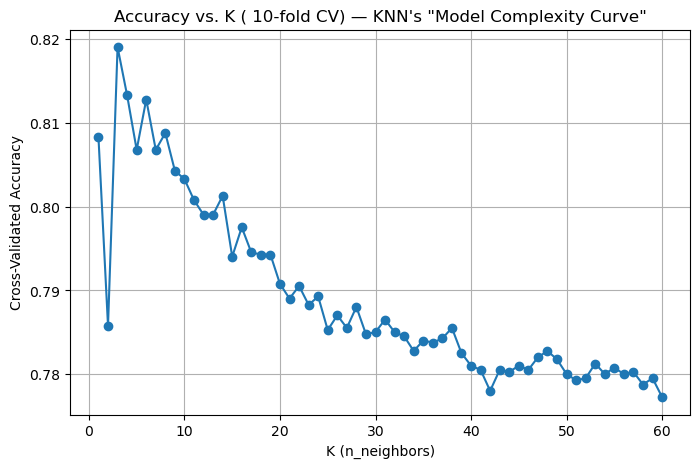

In [15]:
best_metric = grid_search.best_params_["metric"]

k_range = range(1, 61)
k_scores = []

try:
    for k in k_range:
        temp_knn = KNeighborsClassifier(n_neighbors=k, weights="uniform", metric=best_metric)
        scores = cross_val_score(temp_knn, X_train, y_train, cv=10, scoring="accuracy")
        k_scores.append(scores.mean())
except (ValueError, RuntimeError) as e:
    print(f"Error during K sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, k_scores, marker="o")
    plt.title("Accuracy vs. K (10-fold CV) — KNN's \"Model Complexity Curve\"")
    plt.xlabel("K (n_neighbors)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## Decision Threshold Optimization (Youden's J Statistic) 
Rather than relying on the default 0.5 probability cutoff, this finds the threshold that maximizes **Youden's J = Sensitivity + Specificity − 1**, using the ROC curve. This is a formula distinct from accuracy/precision/recall/F1, and can improve overall classification accuracy by shifting the decision boundary to better suit the data's true positive/negative trade-off.

In [10]:
try:
    y_probs = best_knn.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_pred_optimal = (y_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold: {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    print()
    print("Accuracy with optimal threshold:", accuracy_score(y_test, y_pred_optimal))
    print(classification_report(y_test, y_pred_optimal))
    log_result("Grid Search + Youden's J", y_test, y_pred_optimal)

Optimal threshold: 0.6667
Youden's J at this threshold: 0.6047

Accuracy with optimal threshold: 0.807
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       438
           1       0.82      0.84      0.83       562

    accuracy                           0.81      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.81      0.81      1000

[Logged] Grid Search + Youden's J: 0.8070


## Gaussian Weighted Voting 
KNN's model-specific \"extra formula\": instead of `uniform` (every neighbor votes equally) or `distance` (weight = 1/d, which can blow up sharply as d → 0), a **Gaussian kernel weight** gives closer neighbors a smoothly decaying influence: $$w_i = \\exp\\left(-\\frac{d_i^2}{2\\sigma^2}\\right)$$ This avoids the near-total self-voting blowup that caused the earlier 100% training-accuracy issue with `weights='distance'`, while still letting nearby points matter more than far ones. `sigma` controls how quickly influence decays with distance.

In [11]:
def gaussian_weights(distances, sigma=1.0):
    return np.exp(-(distances**2) / (2 * sigma**2))

try:
    knn_gaussian = KNeighborsClassifier(n_neighbors=15, weights=gaussian_weights)
    knn_gaussian.fit(X_train, y_train)
    gaussian_pred = knn_gaussian.predict(X_test)
except (ValueError, RuntimeError) as e:
    print(f"Error training Gaussian-weighted KNN: {e}")
else:
    gaussian_accuracy = accuracy_score(y_test, gaussian_pred)
    print("Gaussian Weighting Accuracy:", gaussian_accuracy)
    log_result("Gaussian Weighted Voting", y_test, gaussian_pred)

Gaussian Weighting Accuracy: 0.832
[Logged] Gaussian Weighted Voting: 0.8320


## Result Summary & Save Model

In [12]:
report = classification_report(y_test, best_pred, output_dict=True)

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Train-Test Gap"],
    "Value": [
        accuracy_score(y_test, best_pred),
        report["weighted avg"]["precision"],
        report["weighted avg"]["recall"],
        report["weighted avg"]["f1-score"],
        train_accuracy - test_accuracy
    ]
})

summary

,Metric,Value
0,Accuracy,0.807000
1,Precision,0.806576
2,Recall,0.807000
3,F1-score,0.806650
4,Train-Test Gap,0.099156


## Full Accuracy Progression Log
Every stage's accuracy, in the order it was calculated — shows how (or whether) each technique actually improved on the previous stage.

In [13]:
log_df = pd.DataFrame(results_log)
log_df

,Stage,Accuracy
0,Baseline (n_neighbors=15),0.777000
1,"Grid Search (10-fold CV, best score)",0.819063
2,Grid Search Tuned (test set),0.807000
3,10-Fold Cross-Validation (mean),0.819063
4,Grid Search + Youden's J,0.807000
5,Gaussian Weighted Voting,0.832000


In [14]:
# save the trained model
try:
    joblib.dump(best_knn, 'knn_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print("Model saved successfully!")

Model saved successfully!
